# logistic regression

1.Data exploration:
a. load data set and perform EDA
b.Examine the features , their types and summary statistics
c.visualization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


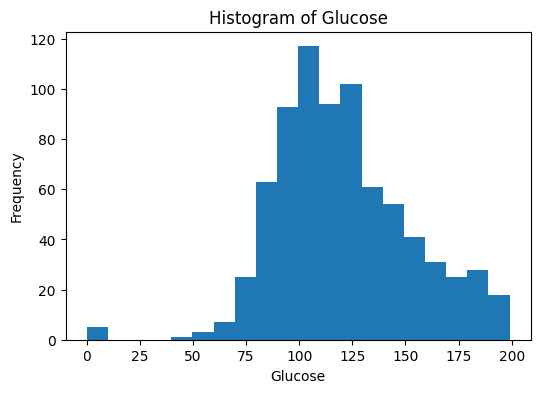

In [ ]:
#HISTOGRAM
plt.figure(figsize=(6,4))

plt.hist(df['Glucose'], bins=20)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Histogram of Glucose")

plt.show()

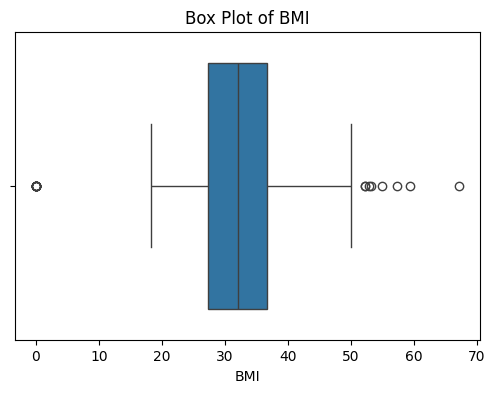

In [ ]:
#BOX PLOTS
plt.figure(figsize=(6,4))

sns.boxplot(x=df['BMI'])

plt.title("Box Plot of BMI")

plt.show()

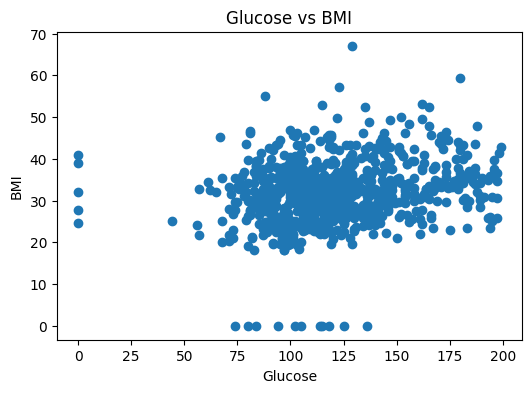

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(df['Glucose'], df['BMI'])

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")

plt.show()

Patterns Observed
Glucose strongly correlates with diabetes outcome
BMI and Age positively affect diabetes occurrence
Outliers present in Insulin and BMI
Some columns contain invalid zero values

2. Data Preprocessing
a. Handle Missing Values
b. Encode categorical variables.

In [ ]:
cols = ['Glucose', 'BloodPressure',
        'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [ ]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1752/2832450841.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
#OULIER TREATMENT
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print(df.shape)

(375, 9)


In [ ]:
#MULTICOLLENERITY
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop('Outcome', axis=1)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                    Feature        VIF
0               Pregnancies   3.451967
1                   Glucose  20.632397
2             BloodPressure  61.909878
3             SkinThickness  47.267336
4                   Insulin  88.264461
5                       BMI  33.929021
6  DiabetesPedigreeFunction   3.676298
7                       Age  14.131475


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

3.MODEL TRAINING
Separate Features and Target
Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

**MODEL EVALUATION**
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7333333333333333


In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6666666666666666


In [ ]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6206896551724138


In [ ]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6428571428571429


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7991004497751124


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.79        46
           1       0.67      0.62      0.64        29

    accuracy                           0.73        75
   macro avg       0.72      0.71      0.72        75
weighted avg       0.73      0.73      0.73        75



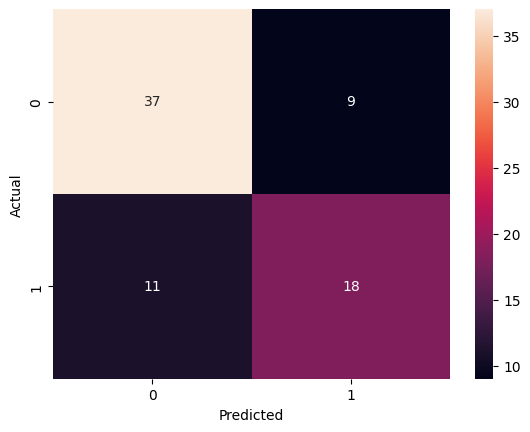

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

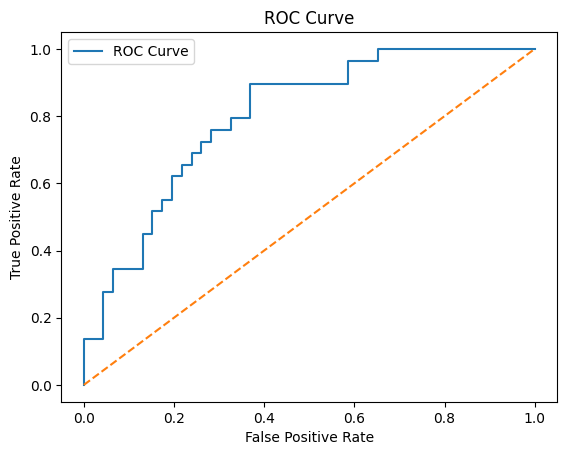

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**5.INTERPRETATION**


a. Interpret the coefficients of the logistic regression model.


b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

                    Feature  Coefficient
0               Pregnancies     0.340599
1                   Glucose     1.251208
2             BloodPressure    -0.138360
3             SkinThickness     0.271745
4                   Insulin    -0.193696
5                       BMI     0.617958
6  DiabetesPedigreeFunction     0.407788
7                       Age     0.070475


Important Features

Usually:

Glucose
BMI
Age
Pregnancies

have strong positive influence.

**b. Feature Significance**
**Glucose**

Most significant predictor.

Higher glucose increases diabetes probability.

**BMI**

Higher BMI indicates obesity risk.

**Age**

Older individuals show higher diabetes risk.

**Insulin**

Can influence diabetes diagnosis.

6.DEPLOYMENT WITH STREAMLIT

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.5 MB/s eta 0:00:00


In [ ]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))

pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [ ]:
import streamlit as st
import pickle
import numpy as np

# Load model
model = pickle.load(open('model.pkl', 'rb'))

scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("Diabetes Prediction App")

# Inputs
pregnancies = st.number_input("Pregnancies")
glucose = st.number_input("Glucose")
blood_pressure = st.number_input("Blood Pressure")
skin_thickness = st.number_input("Skin Thickness")
insulin = st.number_input("Insulin")
bmi = st.number_input("BMI")
dpf = st.number_input("Diabetes Pedigree Function")
age = st.number_input("Age")

# Prediction
if st.button("Predict"):

    features = np.array([[pregnancies,
                          glucose,
                          blood_pressure,
                          skin_thickness,
                          insulin,
                          bmi,
                          dpf,
                          age]])

    features = scaler.transform(features)

    prediction = model.predict(features)

    if prediction[0] == 1:
        st.error("Person is Diabetic")
    else:
        st.success("Person is Not Diabetic")

2026-05-26 06:07:19.199 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.508 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-26 06:07:19.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 06:07:19.517 Thread 'MainThread': mi

INTERVIEW QUESTIONS?

1. What is the difference between precision and recall?

2. What is cross-validation, and why is it important in binary classification?




Precision

Precision measures how many predicted positive cases are actually positive.

Formula:

Precision = TP / (TP + FP)

High precision means fewer false positives.
Important when false positives are costly.

Example: Spam email detection.

Recall

Recall measures how many actual positive cases are correctly identified.

Formula:

Recall = TP / (TP + FN)

High recall means fewer false negatives.
Important in medical diagnosis.

Example: Disease prediction systems.

Difference Summary
Precision	Recall
Focuses on prediction accuracy of positive class	Focuses on capturing all actual positives
Minimizes False Positives	Minimizes False Negatives
Useful when FP is costly	Useful when FN is costly
2. What is Cross-Validation and Why is it Important?
Definition

Cross-validation is a model evaluation technique used to assess how well a machine learning model generalizes to unseen data.

K-Fold Cross Validation
Dataset is divided into K equal folds.
Model trains on K-1 folds.
Remaining fold is used for testing.
Process repeats K times.
Average score is calculated.
Example

5-Fold Cross Validation:

Train on 4 folds
Test on 1 fold
Repeat 5 times

In [ ]:
!pip install streamlit pyngrok joblib

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib

# Load dataset
df = pd.read_csv("diabetes.csv")

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "logistic_model.pkl")

print("Model trained and saved")

Model trained and saved


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("logistic_model.pkl")

st.title("Diabetes Prediction App")

st.write("Enter Patient Details")

Pregnancies = st.number_input("Pregnancies", min_value=0)

Glucose = st.number_input("Glucose", min_value=0)

BloodPressure = st.number_input("Blood Pressure", min_value=0)

SkinThickness = st.number_input("Skin Thickness", min_value=0)

Insulin = st.number_input("Insulin", min_value=0)

BMI = st.number_input("BMI", min_value=0.0)

DiabetesPedigreeFunction = st.number_input(
    "Diabetes Pedigree Function",
    min_value=0.0
)

Age = st.number_input("Age", min_value=1)

if st.button("Predict"):

    input_data = np.array([
        [
            Pregnancies,
            Glucose,
            BloodPressure,
            SkinThickness,
            Insulin,
            BMI,
            DiabetesPedigreeFunction,
            Age
        ]
    ])

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("Person is Diabetic")
    else:
        st.success("Person is Non-Diabetic")

Writing app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3EFaHOvKcUhlQKE2Ypf2wyoy3XA_4NvnSQQf1QWrAqzDvQagK")



In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://imitate-onyx-fit.ngrok-free.dev" -> "http://localhost:8501"
